# Task 5: Personal Loan / Term Deposit Acceptance Prediction

## Research Purpose

This notebook studies whether a banking campaign can identify customers who are more likely to accept a term deposit or similar personal banking offer. The business goal is campaign prioritization: fewer wasted contacts, better targeting, and clearer understanding of which customer groups respond.

The UCI Bank Marketing target is `y`: `yes` means the customer subscribed and `no` means the customer did not. I treat the task as response prediction, not guaranteed long-term profitability. I also handle `duration` carefully: it is highly predictive after a call happens, but it is not available before choosing whom to contact, so I compare models with and without it.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette=["#1D3557", "#E76F51", "#2A9D8F", "#F4A261"],
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    },
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## Dataset Loading and First Look

In [2]:
local_path = DATA_DIR / "bank-full.csv"
if not local_path.exists():
    raise FileNotFoundError(f"Expected local dataset at {local_path}.")

raw_df = pd.read_csv(local_path, sep=";")

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
raw_df.head()

Rows: 45,211
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Research note:** This is a direct-marketing dataset. Some fields describe the customer before the campaign, while others describe the campaign interaction itself. That distinction matters because a pre-campaign targeting model should not depend on information only known after the phone call.

In [3]:
quality_report = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_values": raw_df.isna().sum(),
        "missing_rate": raw_df.isna().mean(),
        "unknown_values": (raw_df == "unknown").sum(),
        "unknown_rate": (raw_df == "unknown").mean(),
        "unique_values": raw_df.nunique(dropna=True),
    }
).sort_values(["unknown_values", "unique_values"], ascending=[False, False])

display(quality_report)
display(raw_df["y"].value_counts().rename("response_count"))
display(raw_df["y"].value_counts(normalize=True).rename("response_rate").round(3))

,dtype,missing_values,missing_rate,unknown_values,unknown_rate,unique_values
poutcome,object,0,0.0,36959,0.817478,4
contact,object,0,0.0,13020,0.287983,3
education,object,0,0.0,1857,0.041074,4
job,object,0,0.0,288,0.006370,12
balance,int64,0,0.0,0,0.000000,7168
duration,int64,0,0.0,0,0.000000,1573
pdays,int64,0,0.0,0,0.000000,559
age,int64,0,0.0,0,0.000000,77
campaign,int64,0,0.0,0,0.000000,48
previous,int64,0,0.0,0,0.000000,41


y
no     39922
yes     5289
Name: response_count, dtype: int64

y
no     0.883
yes    0.117
Name: response_rate, dtype: float64

## Cleaning and Feature Setup

In [4]:
df = raw_df.copy()
df["accepted"] = df["y"].map({"yes": 1, "no": 0})
df = df.drop(columns=["y"])

target = "accepted"

numeric_features = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
]

df["was_previously_contacted"] = (df["pdays"] != -1).astype(int)
df["has_prior_campaign_success"] = (df["poutcome"] == "success").astype(int)
df["has_personal_loan"] = (df["loan"] == "yes").astype(int)
df["has_housing_loan"] = (df["housing"] == "yes").astype(int)
df["age_band"] = pd.cut(
    df["age"],
    bins=[17, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "61+"],
)

engineered_numeric = numeric_features + [
    "was_previously_contacted",
    "has_prior_campaign_success",
    "has_personal_loan",
    "has_housing_loan",
]
model_categorical = categorical_features + ["age_band"]

pre_call_numeric = [col for col in engineered_numeric if col != "duration"]

X = df[engineered_numeric + model_categorical]
X_pre_call = df[pre_call_numeric + model_categorical]
y = df[target]

display(df.head())
print(f"Acceptance rate: {y.mean():.3f}")

,age,job,marital,education,default,balance,housing,loan,contact,day,...,campaign,pdays,previous,poutcome,accepted,was_previously_contacted,has_prior_campaign_success,has_personal_loan,has_housing_loan,age_band
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,1,-1,0,unknown,0,0,0,0,1,51-60
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,1,-1,0,unknown,0,0,0,0,1,41-50
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,1,-1,0,unknown,0,0,0,1,1,31-40
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,1,-1,0,unknown,0,0,0,0,1,41-50
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,1,-1,0,unknown,0,0,0,0,0,31-40


Acceptance rate: 0.117


## Descriptive Statistical Analytics

In [5]:
numeric_summary = (
    df.groupby(target)[engineered_numeric]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

numeric_summary

age                      balance                            day  \
          count   mean median    std   count     mean median     std  count   
accepted                                                                      
0         39922  40.84   39.0  10.17   39922  1303.71  417.0  2974.2  39922   
1          5289  41.67   38.0  13.50    5289  1804.27  733.0  3501.1   5289   

                 ... has_prior_campaign_success       has_personal_loan        \
           mean  ...                     median   std             count  mean   
accepted         ...                                                            
0         15.89  ...                        0.0  0.11             39922  0.17   
1         15.16  ...                        0.0  0.39              5289  0.09   

                      has_housing_loan                     
         median   std            count  mean median   std  
accepted                                                   
0           0.0  0.38            39922  0.58    1.0  0.49  
1           0.0  0.29             5289  0.37    0.0  0.48  

[2 rows x 44 columns]

In [6]:
segment_tables = {}
for col in ["job", "marital", "education", "housing", "loan", "contact", "poutcome", "age_band"]:
    segment_tables[col] = (
        df.groupby(col, observed=False)[target]
        .agg(customers="count", acceptance_rate="mean")
        .sort_values("acceptance_rate", ascending=False)
        .round(3)
    )

display(segment_tables["job"].head(10))
display(segment_tables["poutcome"])

,customers,acceptance_rate
job,,
student,938,0.287
retired,2264,0.228
unemployed,1303,0.155
management,9458,0.138
admin.,5171,0.122
self-employed,1579,0.118
unknown,288,0.118
technician,7597,0.111
services,4154,0.089


,customers,acceptance_rate
poutcome,,
success,1511,0.647
other,1840,0.167
failure,4901,0.126
unknown,36959,0.092


**Research note:** Acceptance is rare compared with non-response, so segment rates matter more than raw counts alone. A large job group may create many acceptances, while a smaller group may have a higher acceptance rate. Campaign strategy needs both views.

## Exploratory Visual Analytics

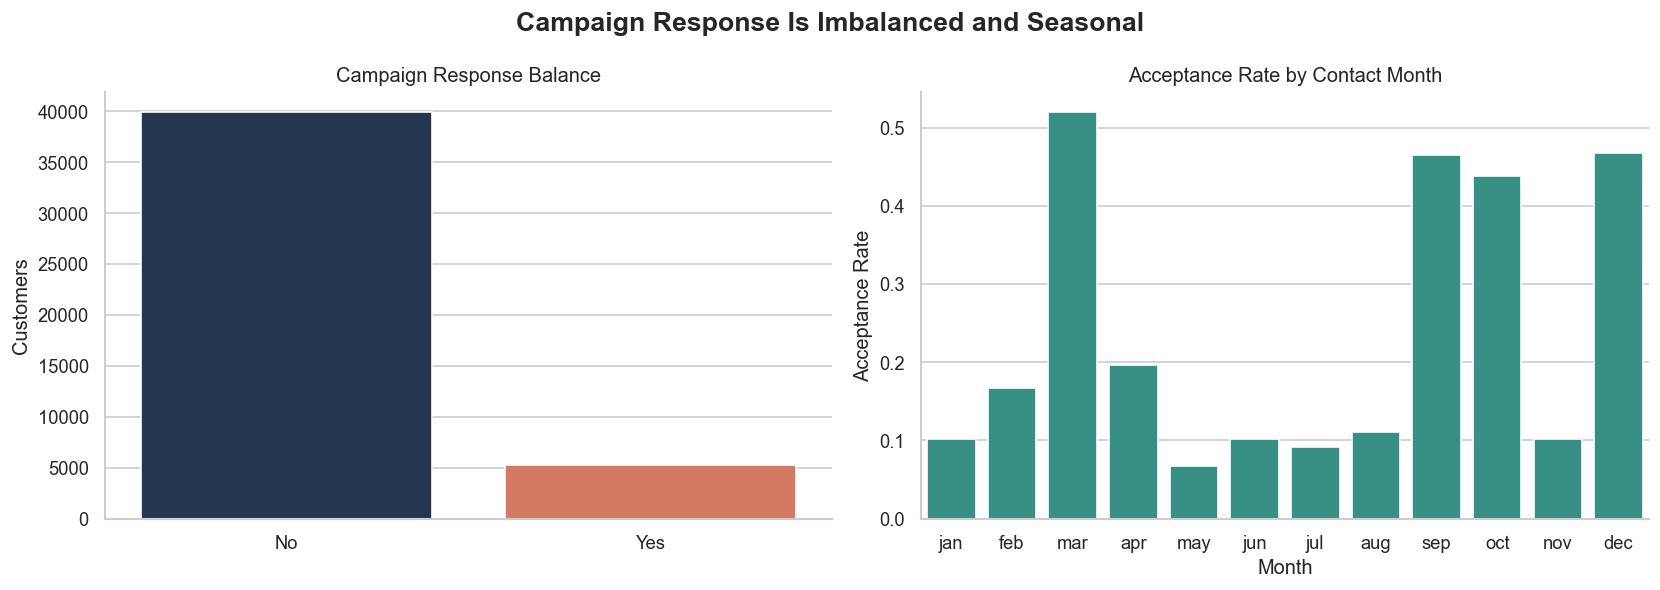

In [7]:
plot_df = df.copy()
plot_df["Campaign outcome"] = plot_df[target].map({0: "No", 1: "Yes"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=plot_df, x="Campaign outcome", ax=axes[0], palette=["#1D3557", "#E76F51"])
axes[0].set_title("Campaign Response Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customers")

month_rates = df.groupby("month")[target].mean().reindex(
    ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
)
sns.barplot(x=month_rates.index, y=month_rates.values, ax=axes[1], color="#2A9D8F")
axes[1].set_title("Acceptance Rate by Contact Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Acceptance Rate")

fig.suptitle("Campaign Response Is Imbalanced and Seasonal", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task5_response_balance_month.png", dpi=180, bbox_inches="tight")
plt.show()

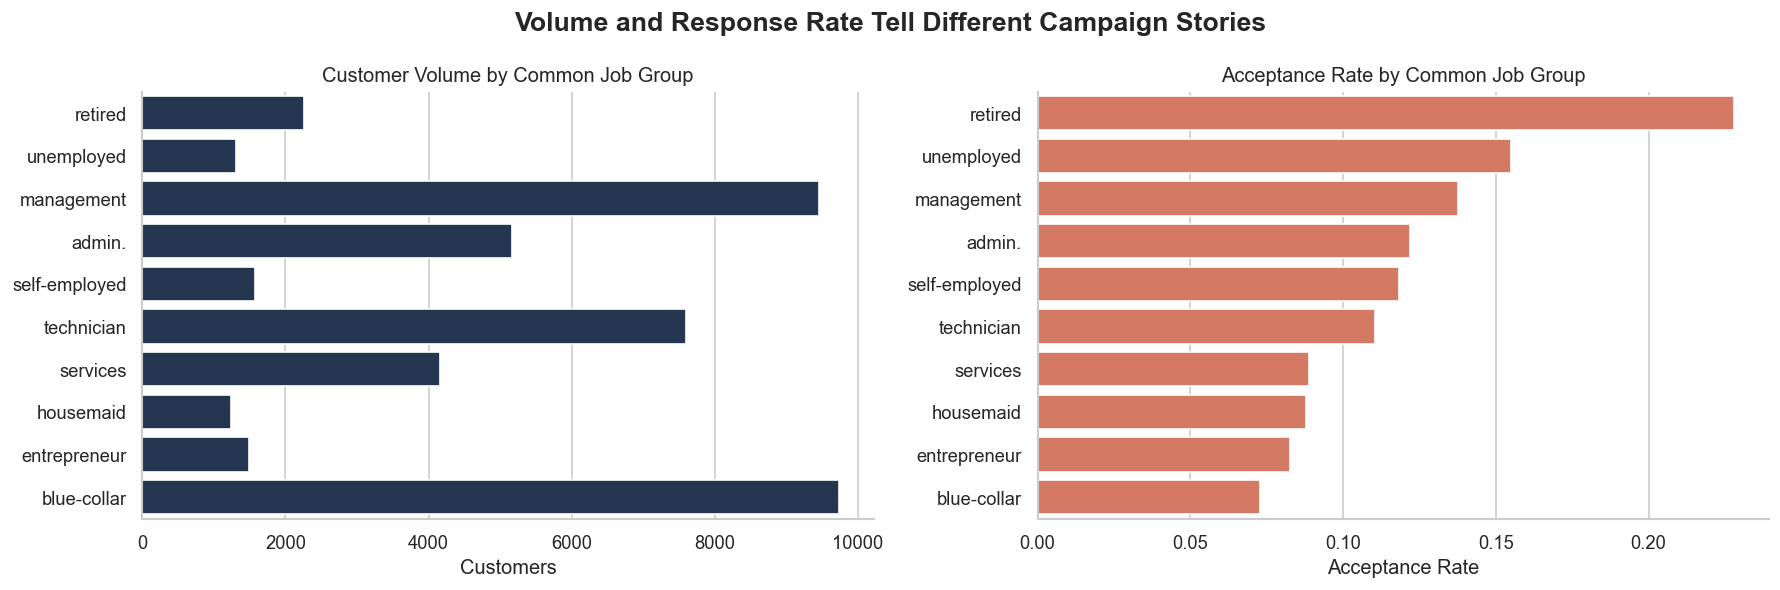

,job,customers,acceptance_rate
0,retired,2264,0.228
1,unemployed,1303,0.155
2,management,9458,0.138
3,admin.,5171,0.122
4,self-employed,1579,0.118
5,technician,7597,0.111
6,services,4154,0.089
7,housemaid,1240,0.088
8,entrepreneur,1487,0.083
9,blue-collar,9732,0.073


In [8]:
top_jobs = df["job"].value_counts().head(10).index
job_rates = (
    df[df["job"].isin(top_jobs)]
    .groupby("job")[target]
    .agg(customers="count", acceptance_rate="mean")
    .sort_values("acceptance_rate", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=job_rates, y="job", x="customers", ax=axes[0], color="#1D3557")
axes[0].set_title("Customer Volume by Common Job Group")
axes[0].set_xlabel("Customers")
axes[0].set_ylabel("")

sns.barplot(data=job_rates, y="job", x="acceptance_rate", ax=axes[1], color="#E76F51")
axes[1].set_title("Acceptance Rate by Common Job Group")
axes[1].set_xlabel("Acceptance Rate")
axes[1].set_ylabel("")

fig.suptitle("Volume and Response Rate Tell Different Campaign Stories", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task5_job_volume_acceptance.png", dpi=180, bbox_inches="tight")
plt.show()

job_rates.round(3)

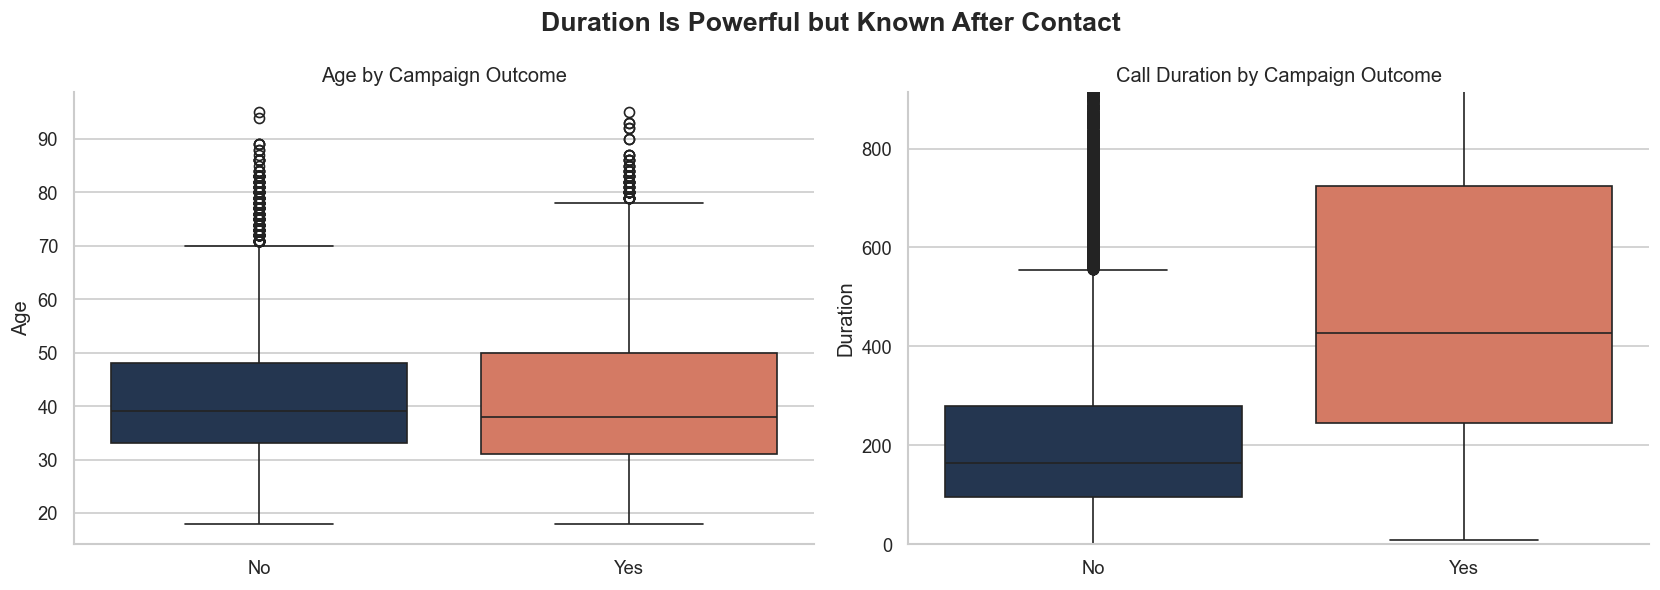

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x="Campaign outcome", y="age", ax=axes[0], palette=["#1D3557", "#E76F51"])
axes[0].set_title("Age by Campaign Outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("Age")

sns.boxplot(data=plot_df, x="Campaign outcome", y="duration", ax=axes[1], palette=["#1D3557", "#E76F51"])
axes[1].set_ylim(0, df["duration"].quantile(0.97))
axes[1].set_title("Call Duration by Campaign Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("Duration")

fig.suptitle("Duration Is Powerful but Known After Contact", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task5_age_duration_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

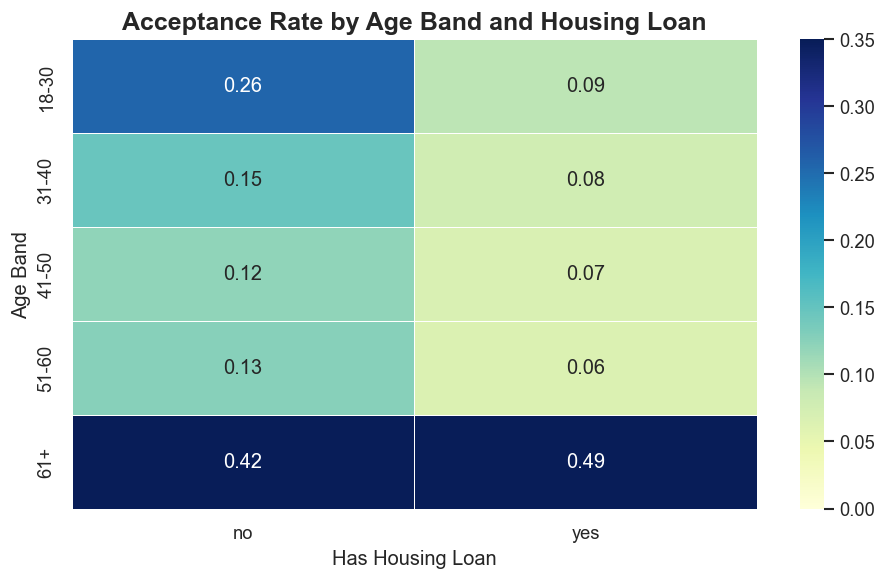

housing,no,yes
age_band,,
18-30,0.257,0.094
31-40,0.147,0.077
41-50,0.120,0.068
51-60,0.127,0.064
61+,0.418,0.488


In [10]:
heatmap_rates = (
    df.groupby(["age_band", "housing"], observed=False)[target]
    .mean()
    .reset_index()
    .pivot(index="age_band", columns="housing", values=target)
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_rates, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, vmin=0, vmax=0.35)
plt.title("Acceptance Rate by Age Band and Housing Loan", fontsize=15, fontweight="bold")
plt.xlabel("Has Housing Loan")
plt.ylabel("Age Band")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task5_age_housing_acceptance_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

heatmap_rates.round(3)

## Statistical Tests and Meaningful Campaign Signals

In [11]:
test_rows = []

for col in ["age", "balance", "duration", "campaign", "pdays", "previous"]:
    accepted = df.loc[df[target] == 1, col].dropna()
    rejected = df.loc[df[target] == 0, col].dropna()
    stat, p_value = stats.mannwhitneyu(accepted, rejected, alternative="two-sided")
    test_rows.append(
        {
            "feature": col,
            "test": "Mann-Whitney U",
            "accepted_median": accepted.median(),
            "not_accepted_median": rejected.median(),
            "p_value": p_value,
        }
    )

for col in categorical_features + ["age_band", "was_previously_contacted", "has_prior_campaign_success"]:
    contingency = pd.crosstab(df[col], df[target])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    test_rows.append(
        {
            "feature": col,
            "test": "Chi-square",
            "accepted_median": np.nan,
            "not_accepted_median": np.nan,
            "p_value": p_value,
        }
    )

test_table = pd.DataFrame(test_rows).sort_values("p_value")
test_table["p_value"] = test_table["p_value"].map(lambda value: f"{value:.3e}")
test_table.round(2)

,feature,test,accepted_median,not_accepted_median,p_value
2,duration,Mann-Whitney U,426.0,164.0,0.000e+00
14,poutcome,Chi-square,NaN,NaN,0.000e+00
13,month,Chi-square,NaN,NaN,0.000e+00
17,has_prior_campaign_success,Chi-square,NaN,NaN,0.000e+00
15,age_band,Chi-square,NaN,NaN,5.154e-291
5,previous,Mann-Whitney U,0.0,0.0,3.492e-283
16,was_previously_contacted,Chi-square,NaN,NaN,9.550e-277
4,pdays,Mann-Whitney U,-1.0,-1.0,2.484e-235
12,contact,Chi-square,NaN,NaN,1.252e-225
10,housing,Chi-square,NaN,NaN,2.919e-192


**Research note:** Duration is statistically and practically strong, but it answers a different question: how does the call behave once it happens? For deciding who to contact before the call, prior outcome, contact type, loans, month, age, and balance are more realistic inputs.

## Correlation, Variance, and Multicollinearity

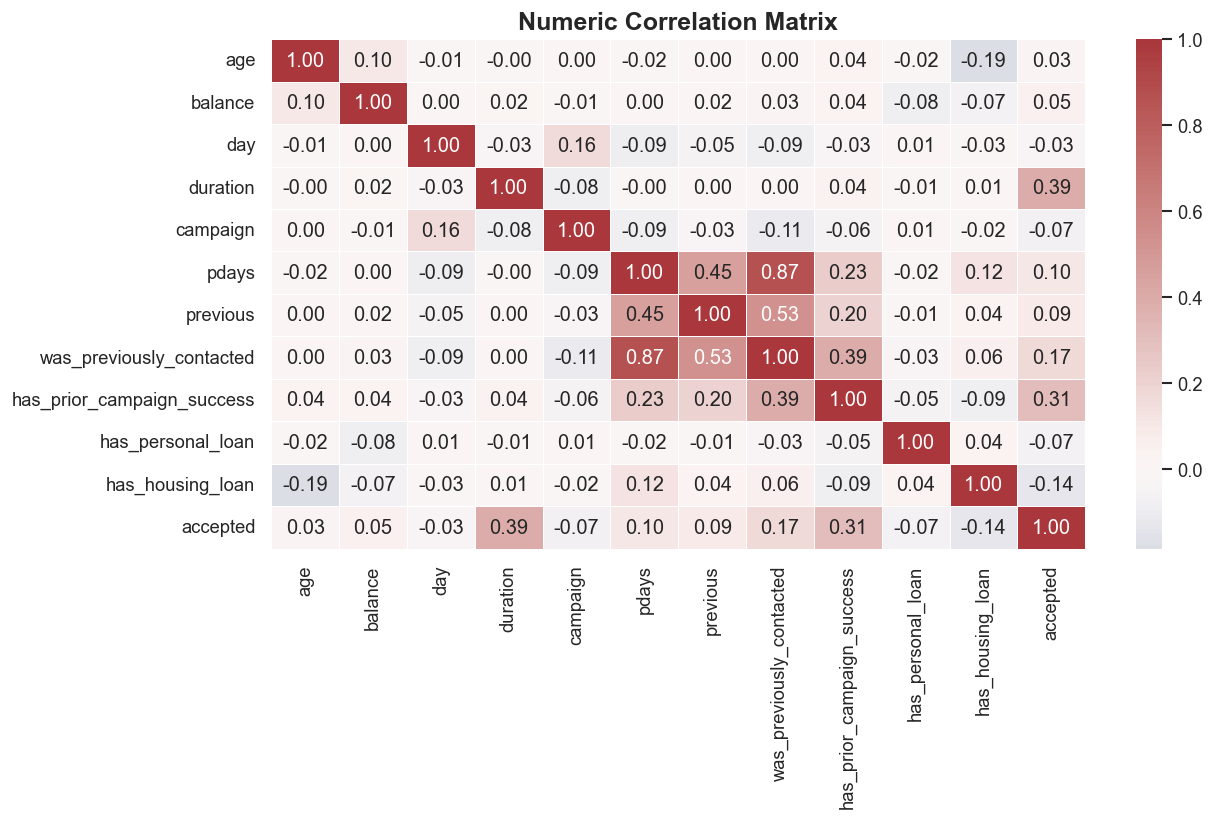

duration                      0.395
has_prior_campaign_success    0.307
was_previously_contacted      0.167
pdays                         0.104
previous                      0.093
balance                       0.053
age                           0.025
day                          -0.028
has_personal_loan            -0.068
campaign                     -0.073
has_housing_loan             -0.139
Name: accepted, dtype: float64

In [12]:
corr_cols = engineered_numeric + [target]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Numeric Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task5_correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

corr[target].drop(target).sort_values(ascending=False).round(3)

In [13]:
def calculate_vif(frame, columns):
    numeric = frame[columns].replace([np.inf, -np.inf], np.nan).dropna()
    numeric = numeric.loc[:, numeric.nunique() > 1]
    return (
        pd.DataFrame(
            {
                "feature": numeric.columns,
                "vif": [
                    variance_inflation_factor(numeric.values, i)
                    for i in range(numeric.shape[1])
                ],
            }
        )
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )

calculate_vif(df, engineered_numeric).round(2)

,feature,vif
0,was_previously_contacted,6.65
1,age,5.48
2,pdays,5.20
3,day,4.08
4,has_housing_loan,2.09
5,duration,1.92
6,campaign,1.84
7,previous,1.49
8,has_prior_campaign_success,1.32
9,balance,1.23


**Research note:** Some engineered indicators intentionally overlap with original campaign fields. That is useful for interpretation, but it means coefficient explanations should focus on direction and relative signal rather than pretending every feature is independent.

## VADER Sentiment Applicability Check

In [14]:
text_columns = [
    col for col in df.columns
    if pd.api.types.is_object_dtype(df[col])
    and col not in categorical_features
    and col != "age_band"
]

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    vader_available = True
except ImportError:
    vader_available = False

vader_audit = pd.DataFrame(
    {
        "check": ["free_text_columns_available", "vader_package_available", "sentiment_model_used"],
        "result": [bool(text_columns), vader_available, bool(text_columns and vader_available)],
        "note": [
            f"Potential text columns: {text_columns}" if text_columns else "No call transcripts, customer comments, or complaint text exists in this dataset.",
            "VADER is available for genuine campaign text." if vader_available else "Install vaderSentiment before applying sentiment scoring.",
            "Not applied here because all object columns are coded categories, not sentiment-bearing language.",
        ],
    }
)

vader_audit

,check,result,note
0,free_text_columns_available,False,"No call transcripts, customer comments, or com..."
1,vader_package_available,False,Install vaderSentiment before applying sentime...
2,sentiment_model_used,False,Not applied here because all object columns ar...


## Model Training: With-Duration vs Pre-Call Targeting

In [15]:
def make_logistic_pipeline(numeric_cols, categorical_cols):
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ]
    )
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    solver="saga",
                    penalty="l2",
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_pre_train, X_pre_test, _, _ = train_test_split(
    X_pre_call,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

with_duration_model = make_logistic_pipeline(engineered_numeric, model_categorical)
pre_call_model = make_logistic_pipeline(pre_call_numeric, model_categorical)

candidate_models = {
    "With duration available": (with_duration_model, X_train, X_test),
    "Pre-call targeting only": (pre_call_model, X_pre_train, X_pre_test),
}

comparison_rows = []
for name, (candidate, train_frame, test_frame) in candidate_models.items():
    candidate.fit(train_frame, y_train)
    pred = candidate.predict(test_frame)
    proba = candidate.predict_proba(test_frame)[:, 1]
    comparison_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "precision_accept": precision_score(y_test, pred, zero_division=0),
            "recall_accept": recall_score(y_test, pred, zero_division=0),
            "f1_accept": f1_score(y_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, proba),
            "average_precision": average_precision_score(y_test, proba),
        }
    )

pd.DataFrame(comparison_rows).round(3)

,model,accuracy,precision_accept,recall_accept,f1_accept,roc_auc,average_precision
0,With duration available,0.849,0.425,0.825,0.561,0.910,0.538
1,Pre-call targeting only,0.770,0.282,0.625,0.388,0.777,0.412


In [16]:
param_grid = {
    "classifier__C": [0.01, 0.05, 0.1, 0.5, 1, 5],
    "classifier__penalty": ["l1", "l2"],
}

tuned_search = GridSearchCV(
    pre_call_model,
    param_grid=param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
)

tuned_search.fit(X_pre_train, y_train)
tuned_model = tuned_search.best_estimator_
tuned_pred = tuned_model.predict(X_pre_test)
tuned_proba = tuned_model.predict_proba(X_pre_test)[:, 1]

print("Best parameters:", tuned_search.best_params_)
print(f"Tuned pre-call accuracy: {accuracy_score(y_test, tuned_pred):.3f}")
print(f"Tuned pre-call ROC AUC: {roc_auc_score(y_test, tuned_proba):.3f}")
print(f"Tuned pre-call average precision: {average_precision_score(y_test, tuned_proba):.3f}")
print(classification_report(y_test, tuned_pred, target_names=["No", "Yes"]))

Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Tuned pre-call accuracy: 0.768
Tuned pre-call ROC AUC: 0.777
Tuned pre-call average precision: 0.413
              precision    recall  f1-score   support

          No       0.94      0.79      0.86      7985
         Yes       0.28      0.63      0.39      1058

    accuracy                           0.77      9043
   macro avg       0.61      0.71      0.62      9043
weighted avg       0.86      0.77      0.80      9043



## Evaluation and Campaign Threshold Planning

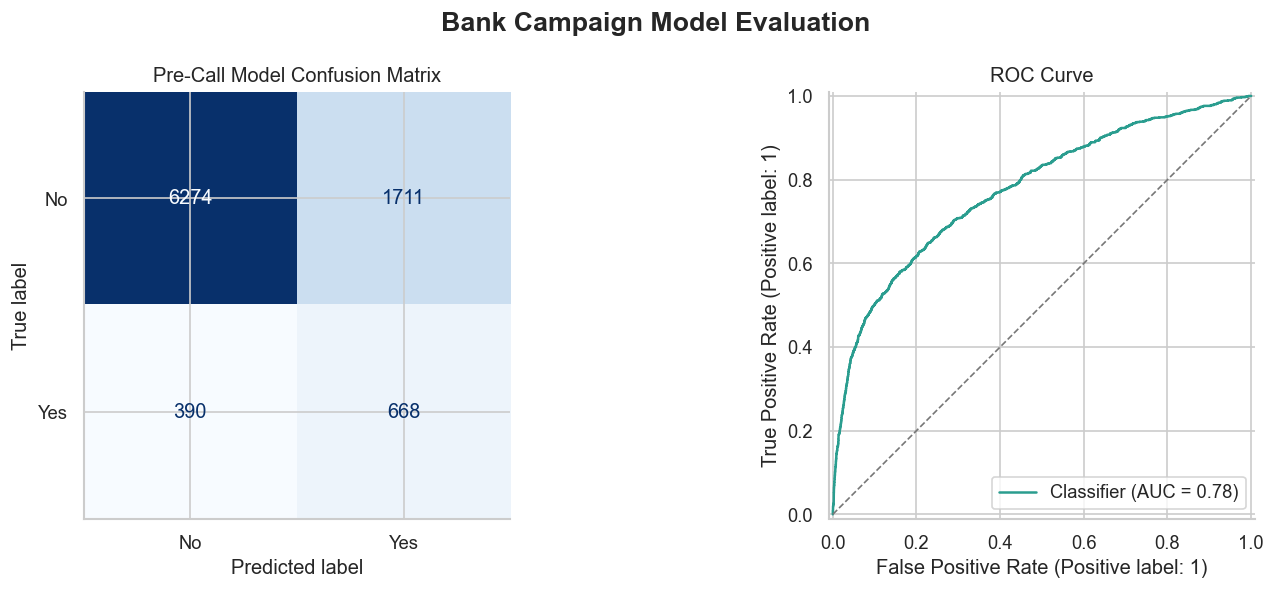

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_pred,
    display_labels=["No", "Yes"],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Pre-Call Model Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, tuned_proba, ax=axes[1], color="#2A9D8F")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#777777", linewidth=1)
axes[1].set_title("ROC Curve")

fig.suptitle("Bank Campaign Model Evaluation", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task5_model_confusion_and_roc.png", dpi=180, bbox_inches="tight")
plt.show()

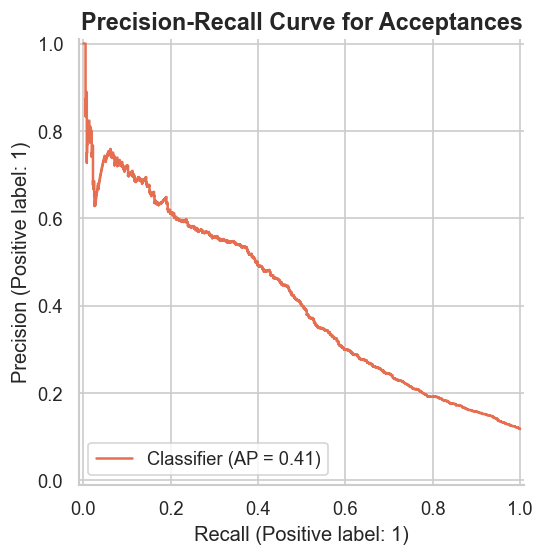

In [18]:
PrecisionRecallDisplay.from_predictions(y_test, tuned_proba, color="#E76F51")
plt.title("Precision-Recall Curve for Acceptances", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task5_precision_recall_curve.png", dpi=180, bbox_inches="tight")
plt.show()

In [19]:
threshold_rows = []
for threshold in np.arange(0.10, 0.71, 0.05):
    threshold_pred = (tuned_proba >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": round(threshold, 2),
            "contact_rate": threshold_pred.mean(),
            "precision_accept": precision_score(y_test, threshold_pred, zero_division=0),
            "recall_accept": recall_score(y_test, threshold_pred, zero_division=0),
            "f1_accept": f1_score(y_test, threshold_pred, zero_division=0),
        }
    )

threshold_table = pd.DataFrame(threshold_rows).round(3)
threshold_table

,threshold,contact_rate,precision_accept,recall_accept,f1_accept
0,0.10,0.994,0.118,0.999,0.210
1,0.15,0.953,0.122,0.990,0.216
2,0.20,0.867,0.130,0.966,0.230
3,0.25,0.793,0.140,0.948,0.244
4,0.30,0.709,0.151,0.916,0.259
5,0.35,0.600,0.169,0.867,0.283
6,0.40,0.475,0.194,0.786,0.311
7,0.45,0.364,0.231,0.717,0.349
8,0.50,0.263,0.281,0.631,0.389
9,0.55,0.185,0.346,0.547,0.424


In [20]:
cv_results = cross_validate(
    tuned_model,
    X_pre_call,
    y,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=1,
)

pd.DataFrame(
    {
        metric.replace("test_", ""): [values.mean(), values.std()]
        for metric, values in cv_results.items()
        if metric.startswith("test_")
    },
    index=["mean", "std"],
).round(3)

,accuracy,precision,recall,f1,roc_auc
mean,0.770,0.281,0.620,0.387,0.771
std,0.002,0.003,0.006,0.004,0.005


**Research note:** A campaign model should be operated as a ranking tool. If the bank can contact only a limited group, it can raise the threshold and accept lower recall. If the campaign is cheap and the goal is broad coverage, it can lower the threshold and accept more false positives.

## Coefficient Review and Segment Insight

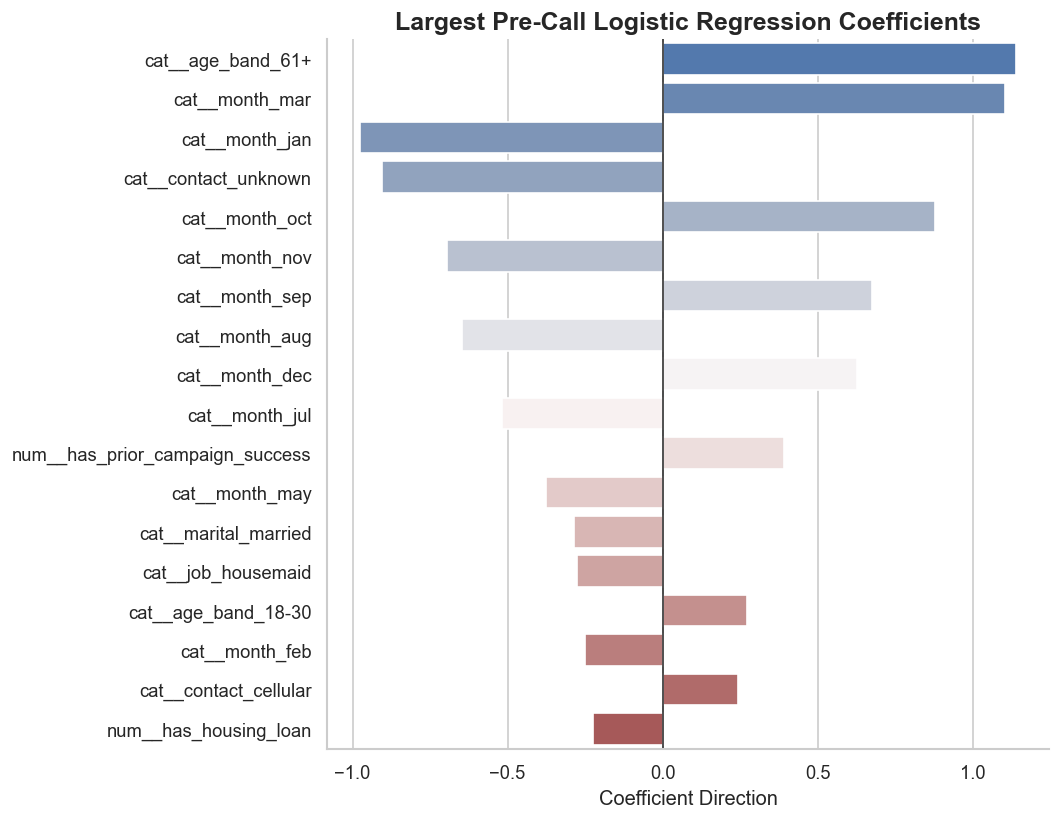

,feature,coefficient
58,cat__age_band_61+,1.139
45,cat__month_mar,1.103
42,cat__month_jan,-0.975
37,cat__contact_unknown,-0.906
48,cat__month_oct,0.878
47,cat__month_nov,-0.695
49,cat__month_sep,0.674
39,cat__month_aug,-0.647
40,cat__month_dec,0.626
43,cat__month_jul,-0.518


In [21]:
feature_names = tuned_model.named_steps["preprocess"].get_feature_names_out()
coefs = tuned_model.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .head(18)
)

plt.figure(figsize=(9, 7))
sns.barplot(data=coef_df, x="coefficient", y="feature", palette="vlag")
plt.axvline(0, color="#333333", linewidth=1)
plt.title("Largest Pre-Call Logistic Regression Coefficients", fontsize=15, fontweight="bold")
plt.xlabel("Coefficient Direction")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task5_logistic_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

coef_df.drop(columns="abs_coefficient").round(3)

In [22]:
group_insights = (
    df.groupby(["job", "marital", "education"], observed=False)[target]
    .agg(customers="count", acceptance_rate="mean")
    .query("customers >= 100")
    .sort_values("acceptance_rate", ascending=False)
    .head(12)
    .round(3)
)

group_insights

customers  acceptance_rate
job           marital  education                            
student       single   secondary        487            0.300
retired       divorced primary          162            0.296
student       single   tertiary         198            0.283
retired       married  unknown          101            0.277
student       single   unknown          152            0.270
retired       married  tertiary         254            0.268
              divorced secondary        165            0.267
unemployed    single   tertiary         134            0.261
self-employed single   tertiary         307            0.244
management    married  unknown          161            0.224
retired       married  primary          602            0.213
                       secondary        774            0.204

## Final Findings

1. The campaign response rate is low, so accuracy alone is misleading.
2. `duration` is highly predictive but only known after a call, so it should not be used as the main pre-call targeting feature.
3. Prior campaign outcome, contact channel, month, age, balance, and loan status are more realistic signals for deciding whom to contact.
4. Not all variables explain campaign response equally. Some fields help with segmentation but are weak as predictive drivers.
5. VADER sentiment analysis is not applied because the dataset has no call transcripts or customer comment text.
6. Regularized logistic regression is appropriate here because the model needs to be interpretable and useful for threshold-based campaign planning.